In [1]:
import numpy as np
import itertools

import jax
import jax.numpy as jnp

# -------------- helper libraries -------------- #
import time
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import logging

# Use installed packages instead of manual sys.path hacking
from utils_training.run_train_toy import TrainerToy
from utils_training.optimize_diffrax_rl import ExperimentRunner as DiffraxExperimentRunner

logging.basicConfig(level=logging.ERROR, filename='error_log.txt')

1. Train the model with Pyomo
    * the main hyperparameter if the number of epochs
2. Initialize JAX model with the trained Pyomo weights and biases

In [23]:
def run(seed=0):
    Trainer = TrainerToy
    tol = 1e-8
    params_model = {
        'layer_widths': [2, 32, 2],
        'act_func': 'tanh',
        'penalty_lambda_reg': 0.1,
        'time_invariant': True,
        'w_init_method': 'xavier',
        'reg_norm': True,
        'skip_collocation': np.inf,
        'params': {
            'tol': tol,
            'acceptable_iter': 0,
            'halt_on_ampl_error': 'yes',
            'print_level': 5,
            'max_iter': 1000
        }
    }

    trainer = Trainer.load_trainer('vdp')
    trainer.train_pyomo(params_model, seed=seed)
    results = {None: trainer.extract_results_pyomo(detailed=True)}
    return trainer, results

trainer, results = run(seed=42)

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/non_parametric_collocation.py:95: UserWarning: Data transposed to match expected dimensions.
  warnings.warn("Data transposed to match expected dimensions.")


seed 42


/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/models/nn_pyomo_base.py:86: UserWarning: y_init should be structured such that each row represents a new time point.
  warnings.warn("y_init should be structured such that each row represents a new time point.")


Redirect logs: False
Ipopt 3.14.16: tol=1e-08
acceptable_iter=0
halt_on_ampl_error=yes
print_level=5
max_iter=1000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.7.1.

Number of nonzeros in equality constraint Jacobian...:   131342
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:    64729

Total number of variables............................:      562
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      562
                     variables with only

In [27]:
results[None].keys()

dict_keys(['time_elapsed', 'direct_model_pred', 'odeint_pred', 'odeint_pred_test', 'mse_train', 'mse_test', 'mse_train_coll', 'mse_test_coll', 'termination', 'seed'])

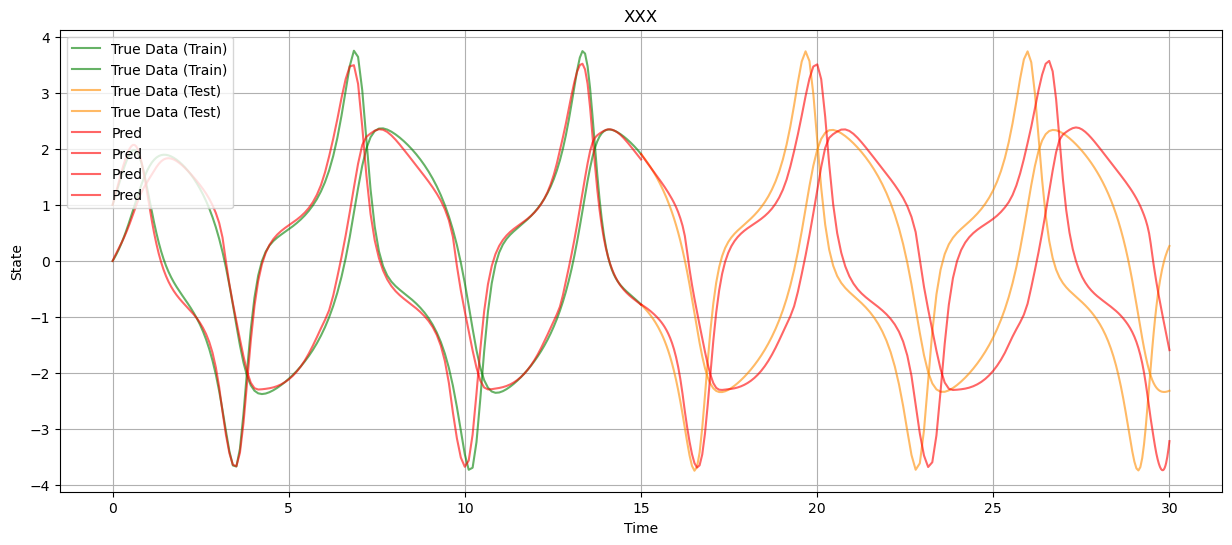

In [29]:
plt.figure(figsize=(15, 6))

plt.plot(trainer.t, trainer.y[:,0], color='green', label='True Data (Train)', alpha = 0.6)
plt.plot(trainer.t, trainer.y[:,1], color='green', label='True Data (Train)', alpha = 0.6)
plt.plot(trainer.t_test, trainer.y_test[:,0], color='#FF8C00', label='True Data (Test)', alpha = 0.6)
plt.plot(trainer.t_test, trainer.y_test[:,1], color='#FF8C00', label='True Data (Test)', alpha = 0.6)

plt.plot(trainer.t, results[None]['odeint_pred'][:, 0], color='red', label='Pred', alpha = 0.6)
plt.plot(trainer.t, results[None]['odeint_pred'][:, 1], color='red', label='Pred', alpha = 0.6)
plt.plot(trainer.t_test, results[None]['odeint_pred_test'][:, 0], color='red', label='Pred', alpha = 0.6)
plt.plot(trainer.t_test, results[None]['odeint_pred_test'][:, 1], color='red', label='Pred', alpha = 0.6)

plt.title(f"XXX")
plt.xlabel("Time")
plt.ylabel("State")
plt.legend(loc ="upper left")
plt.grid(True)
plt.show()

In [30]:
# pickle trained weights and biases
reload = True
if reload:
    wb_trained = trainer.extract_pyomo_weights()

    custom_params = {
        'Dense_0': {
            'kernel': jnp.array(wb_trained['W1']).T,
            'bias': jnp.array(wb_trained['b1'])
        },
        'Dense_1': {
            'kernel': jnp.array(wb_trained['W2']).T,
            'bias': jnp.array(wb_trained['b2'])
        }
    }

    custom_params['time_elapsed'] = list(results.values())[0]['time_elapsed']
    custom_params['layer_width'] = trainer.layer_widths
    with open("results/trained_wb/trained_wb_32.pkl", "wb") as f:
        pickle.dump(custom_params, f)
else:
    with open("results/trained_wb/trained_wb_32.pkl", "rb") as f:
        custom_params = pickle.load(f)

In [31]:
custom_params

{'Dense_0': {'kernel': Array([[ 0.90997572, -0.2927089 , -0.84196362, -0.90997572,  0.64128964,
           0.87033875,  0.16221693, -0.04234251, -0.90997572,  0.90997572,
           0.04234251,  0.49328801,  1.13695955,  0.04234251, -0.136025  ,
          -0.03838695,  0.04234251, -0.84196362,  0.90997572,  0.04234251,
          -0.84196362, -0.90997572, -0.03065632,  0.84196362,  1.6148405 ,
           0.90997572,  0.04234251, -0.04234251,  0.04234251,  0.04234251,
          -3.70675656,  0.04234251],
         [-0.3607345 ,  1.24995587, -0.46291747,  0.3607345 ,  0.63423623,
          -0.29371718,  0.63507016,  0.34717041,  0.3607345 , -0.3607345 ,
          -0.34717041,  0.41823376, -0.47462394, -0.34717041,  1.08004421,
          -1.09294954, -0.34717041, -0.46291747, -0.3607345 , -0.34717041,
          -0.46291747,  0.3607345 ,  0.02820599,  0.46291747,  0.21675182,
          -0.3607345 , -0.34717041,  0.34717041, -0.34717041, -0.34717041,
          -0.89146585, -0.34717041]], dtyp

In [32]:
def run_diffrax(layer_width, learning_rate=1e-3, reg_lambda=1e-5, custom_params=None, pretrain=False, max_iter=1000):
    Trainer = TrainerToy
    trainer = Trainer.load_trainer('vdp', 'uniform', 'jax_diffrax')
    params_model = {
        'layer_widths': layer_width,
        'penalty_lambda_reg': reg_lambda,
        'time_invariant': True,
        'learning_rate': learning_rate,
        'pretrain': [0.2, 1] if pretrain else False,
        'verbose': False,
        'rtol': 1e-3,
        'atol': 1e-6,
        'log': False,
        'act_func': 'tanh',
        'split_time': True,
        'max_iter': max_iter,
        'reg_norm': True
    }

    try:
        trainer.train(params_model, custom_params)
    except Exception as e:
        print(f'Failed to complete training: {e}')
        logging.error(f'Failed to complete training: {e}')
        return None, trainer

    result = trainer.extract_results()
    result["training_loss"] = getattr(trainer, "losses", None)
    return result, trainer

wb_trained = trainer.extract_pyomo_weights()

custom_params = {
    'Dense_0': {
        'kernel': jnp.array(wb_trained['W1']).T,
        'bias': jnp.array(wb_trained['b1'])
    },
    'Dense_1': {
        'kernel': jnp.array(wb_trained['W2']).T,
        'bias': jnp.array(wb_trained['b2'])
    }
}

results_jax, trainer_jax = run_diffrax(trainer.layer_widths, custom_params = custom_params, learning_rate=1e-7, reg_lambda=0.1, max_iter=30000)

Using seed 42 for JAX training.


In [33]:
results_jax

{'time_elapsed': 22.998099088668823,
 'mse_train': Array(0.03233289, dtype=float64),
 'mse_test': Array(1.36718034, dtype=float64),
 'training_loss': [([], [])]}

In [8]:
results_jax

{'time_elapsed': 22.203881978988647,
 'mse_train': Array(0.00539427, dtype=float64),
 'mse_test': Array(0.58456706, dtype=float64),
 'training_loss': [([], [])]}

In [9]:
results_jax_ind, trainer_jax_ind = run_diffrax([2, 64, 2], pretrain = True, learning_rate=1e-3, reg_lambda=1e-5, max_iter= [1000, 30000])

Using seed 42 for JAX training.


In [10]:
results_jax_ind

{'time_elapsed': [2.0652968883514404, 26.39154601097107],
 'mse_train': Array(0.10584856, dtype=float64),
 'mse_test': Array(1.26199533, dtype=float64),
 'training_loss': [([], []), ([], [])]}

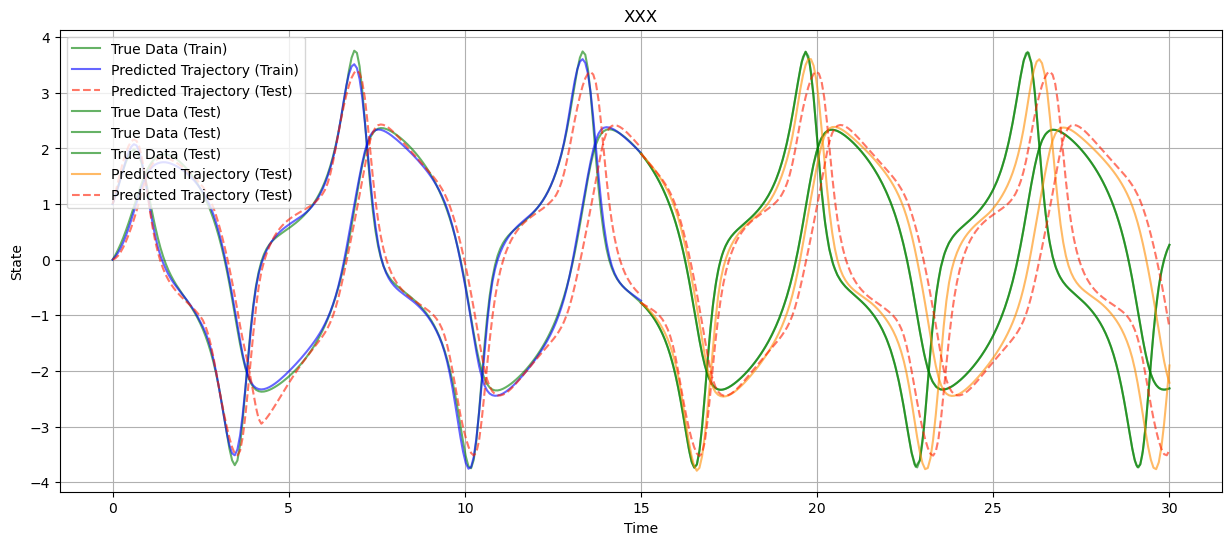

In [13]:
result = trainer_jax.extract_results_diffrax(True)
result_ind = trainer_jax_ind.extract_results_diffrax(True)
y_pred, y_pred_test = result['odeint_pred'], result['odeint_pred_test']
y_pred_ind, y_pred_test_ind = result_ind['odeint_pred'], result_ind['odeint_pred_test']

plt.figure(figsize=(15, 6))

plt.plot(trainer_jax.t, trainer_jax.y[:,0], color = 'green', label='True Data (Train)', alpha = 0.6)
plt.plot(trainer_jax.t, trainer_jax.y[:,1], color = 'green', alpha = 0.6)
plt.plot(trainer_jax.t, y_pred[:,0], color = 'blue', label='Predicted Trajectory (Train)', alpha = 0.6)
plt.plot(trainer_jax.t, y_pred[:,1], color = 'blue', alpha = 0.6)
plt.plot(trainer_jax_ind.t, y_pred_ind[:,0], color='#FF1C00', ls = '--', label='Predicted Trajectory (Test)', alpha = 0.6)
plt.plot(trainer_jax_ind.t, y_pred_ind[:,1], color='#FF1C00', ls = '--', alpha = 0.6)

plt.plot(trainer.t_test, trainer.y_test[:,0], color='green', label='True Data (Test)', alpha = 0.6)
plt.plot(trainer.t_test, trainer.y_test[:,1], color='green', label='True Data (Test)', alpha = 0.6)
plt.plot(trainer_jax.t_test, trainer_jax.y_test[:,0], color='green', label='True Data (Test)', alpha = 0.6)
plt.plot(trainer_jax.t_test, trainer_jax.y_test[:,1], color='green', alpha = 0.6)
plt.plot(trainer_jax.t_test, y_pred_test[:,0], color='#FF8C00', label='Predicted Trajectory (Test)', alpha = 0.6)
plt.plot(trainer_jax.t_test, y_pred_test[:,1], color='#FF8C00', alpha = 0.6)
plt.plot(trainer_jax_ind.t_test, y_pred_test_ind[:,0], color='#FF1C00', ls = '--', label='Predicted Trajectory (Test)', alpha = 0.6)
plt.plot(trainer_jax_ind.t_test, y_pred_test_ind[:,1], color='#FF1C00', ls = '--', alpha = 0.6)

plt.title(f"XXX")
plt.xlabel("Time")
plt.ylabel("State")
plt.legend(loc ="upper left")
plt.grid(True)
plt.show()

In [15]:
results= run_diffrax('training_convergence', trainer.layer_widths, custom_params = custom_params, max_iter=20000, learning_rate=1e-7, reg_lambda=1e-5)
# results = run_diffrax('training_convergence', [2, 64, 2], pretrain = True, learning_rate=1e-3, reg_lambda=1e-5, max_iter=[1000, 30000])
results

100
0
0.010548810558212674
0.5825033589076349
Iteration: 1 / 1


{0: {'time_elapsed': 146.23430609703064,
  'mse_train': Array(0.01054881, dtype=float64),
  'mse_test': Array(0.58250336, dtype=float64),
  'training_loss': [([0.03502465860488416,
     0.10385652244967507,
     0.021274407619125107,
     0.01942563287618129,
     0.024617336494174483,
     0.01872919790722107,
     0.018330438334203402,
     0.017910300140370032,
     0.018376988770011815,
     0.01708774755606192,
     0.016817375288218674,
     0.022356303905927973,
     0.026298515357110697,
     0.02621158019647608,
     0.014959246538552263,
     0.014919720575976307,
     0.014510741878016278,
     0.014549018453732345,
     0.017650009037172378,
     0.025515653172316556,
     0.02536230213613933,
     0.013666591981187264,
     0.013511936030779896,
     0.013103047852657312,
     0.013677284180448734,
     0.01329719711060335,
     0.012812523053006444,
     0.012717132148020146,
     0.012956136283082781,
     0.012707149338766594,
     0.014831040544317694,
     0.012773443

In [16]:
suffix = '_32_pyomo'

reload = True
if reload:
    formatted_time = time.strftime('%Y-%m-%d_%H-%M-%S')
    filename = f'results/diffrax_pyomo_pretraining{suffix}.pkl'
    with open(filename, 'wb') as file:
        pickle.dump(results, file)
        
    print(f"Results saved to {filename}")

if reload:
    formatted_time = time.strftime('%Y-%m-%d_%H-%M-%S')
    filename = f'results/diffrax_pyomo_pretraining_time{suffix}.pkl'
    with open(filename, 'wb') as file:
        pickle.dump(results_jax, file)
        
    print(f"Results saved to {filename}")

Results saved to results/diffrax_pyomo_pretraining_32_pyomo.pkl
Results saved to results/diffrax_pyomo_pretraining_time_32_pyomo.pkl
